In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"F:\Download\credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [ ]:
# is_fraud ---> Target column 
# foreign_transaction, device_trust_score, velocity_last_24h ----> Critical columns

# Data Preprocessing

In [3]:
df.drop(columns=["transaction_id"], inplace=True)
print("✓ Dropped 'transaction_id'.")
 
# Check for missing values
missing = df.isnull().sum()
print(f"\nMissing values per column:\n{missing}")
 
if missing.sum() == 0:
    print("\n✓ No missing values found — no imputation required.")
else:
    # Numerical columns: fill with median (robust to outliers)
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    # Exclude the target from imputation
    num_cols = [c for c in num_cols if c != "is_fraud"]
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
 
    # Categorical columns: fill with mode
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
 
    print(f"\n✓ Imputed {missing.sum()} missing value(s).")
    print(f"  • Numerical  ({len(num_cols)} cols): filled with column median.")
    print(f"  • Categorical ({len(cat_cols)} cols): filled with column mode.")

✓ Dropped 'transaction_id'.

Missing values per column:
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

✓ No missing values found — no imputation required.


In [4]:
df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)
 
merchant_dummies = [c for c in df.columns if c.startswith("merchant_category_")]
print(f"✓ One-Hot Encoded 'merchant_category'.")
print(f"  New dummy columns ({len(merchant_dummies)}): {merchant_dummies}")
print(f"  Updated dataset shape: {df.shape}")

✓ One-Hot Encoded 'merchant_category'.
  New dummy columns (4): ['merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']
  Updated dataset shape: (10000, 12)


In [5]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]
 
# Stratify ensures the fraud ratio is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # critical for imbalanced targets
)
 
print(f"✓ Split complete  (random_state={42}, stratify=True).")
print(f"  X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}     y_test  : {y_test.shape}")
print(f"\n  Fraud rate — train : {y_train.mean():.4f}  |  test : {y_test.mean():.4f}")

✓ Split complete  (random_state=42, stratify=True).
  X_train : (8000, 11)    y_train : (8000,)
  X_test  : (2000, 11)     y_test  : (2000,)

  Fraud rate — train : 0.0151  |  test : 0.0150


In [6]:
SCALE_COLS = [
    "amount",
    "transaction_hour",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
]
 
scaler = StandardScaler()
 
# IMPORTANT: fit ONLY on training data to prevent data leakage
X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])   # transform only
 
print(f"✓ StandardScaler applied to: {SCALE_COLS}")
print(f"\n  Post-scaling X_train stats (scaled cols, first 3):")
print(X_train[SCALE_COLS[:3]].describe().round(4))

✓ StandardScaler applied to: ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

  Post-scaling X_train stats (scaled cols, first 3):
          amount  transaction_hour  device_trust_score
count  8000.0000         8000.0000           8000.0000
mean     -0.0000           -0.0000              0.0000
std       1.0001            1.0001              1.0001
min      -1.0037           -1.6755             -1.7213
25%      -0.7189           -0.8080             -0.8372
50%      -0.3109            0.0595              0.0003
75%       0.3808            0.9270              0.8378
max       6.9534            1.6499              1.7219


In [7]:
fraud_counts = y_train.value_counts()
fraud_ratio  = fraud_counts[1] / len(y_train)
 
print(f"  Training set class distribution:")
print(f"    Non-fraud (0) : {fraud_counts[0]:>5}  ({1 - fraud_ratio:.2%})")
print(f"    Fraud     (1) : {fraud_counts[1]:>5}  ({fraud_ratio:.2%})")
print(f"\n  Imbalance ratio (majority : minority) ≈ {fraud_counts[0] // fraud_counts[1]} : 1")
 
if fraud_ratio < 0.10:
    print("\n  ⚠  Significant imbalance detected.")
    print("     Consider enabling SMOTE (see commented block below).")
else:
    print("\n  ✓  Imbalance is moderate; tree ensembles can handle this natively.")
    print("     SMOTE is optional — enable if CV scores suggest poor recall on fraud.")

  Training set class distribution:
    Non-fraud (0) :  7879  (98.49%)
    Fraud     (1) :   121  (1.51%)

  Imbalance ratio (majority : minority) ≈ 65 : 1

  ⚠  Significant imbalance detected.
     Consider enabling SMOTE (see commented block below).


In [8]:
df.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,84.47,22,0,0,66,3,40,0,True,False,False,False
1,541.82,3,1,0,87,1,64,0,False,False,False,True
2,237.01,17,0,0,49,1,61,0,False,False,True,False
3,164.33,4,0,1,72,3,34,0,False,False,True,False
4,30.53,15,0,0,79,0,44,0,False,True,False,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   amount                         10000 non-null  float64
 1   transaction_hour               10000 non-null  int64  
 2   foreign_transaction            10000 non-null  int64  
 3   location_mismatch              10000 non-null  int64  
 4   device_trust_score             10000 non-null  int64  
 5   velocity_last_24h              10000 non-null  int64  
 6   cardholder_age                 10000 non-null  int64  
 7   is_fraud                       10000 non-null  int64  
 8   merchant_category_Electronics  10000 non-null  bool   
 9   merchant_category_Food         10000 non-null  bool   
 10  merchant_category_Grocery      10000 non-null  bool   
 11  merchant_category_Travel       10000 non-null  bool   
dtypes: bool(4), float64(1), int64(7)
memory usage: 

# Ensemble Models

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",   # handles fraud imbalance
    random_state=42
)
 
# Boosting: trees trained sequentially, each fixing previous errors
gb = HistGradientBoostingClassifier(
    max_iter=100,
    class_weight="balanced",   # handles fraud imbalance
    random_state=42
)
 
# Voting: average the probabilities from RF and GB
voting = VotingClassifier(
    estimators=[("rf", rf), ("gb", gb)],
    voting="soft"
)
 
# Stacking: LR meta-learner learns from RF + GB predictions
stacking = StackingClassifier(
    estimators=[("rf", rf), ("gb", gb)],
    final_estimator=LogisticRegression(class_weight="balanced")
)

In [12]:
models = {
    "Random Forest" : rf,
    "Gradient Boost": gb,
    "Voting"        : voting,
    "Stacking"      : stacking,
}
 
print(f"{'Model':<20} {'PR-AUC':>8} {'F1':>8}  Confusion Matrix")
print("-" * 60)
 
for name, model in models.items():
    model.fit(X_train, y_train)
 
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = model.predict(X_test)
 
    pr_auc = average_precision_score(y_test, y_proba)
    f1     = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
 
    print(f"{name:<20} {pr_auc:>8.4f} {f1:>8.4f}  "
          f"TP={tp} FP={fp} FN={fn} TN={tn}")

Model                  PR-AUC       F1  Confusion Matrix
------------------------------------------------------------
Random Forest          1.0000   0.6047  TP=13 FP=0 FN=17 TN=1970
Gradient Boost         1.0000   0.9831  TP=29 FP=0 FN=1 TN=1970
Voting                 1.0000   0.9831  TP=29 FP=0 FN=1 TN=1970
Stacking               1.0000   0.9231  TP=30 FP=5 FN=0 TN=1965


# Data Visualization

In [ ]:
import seaborn as sns
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

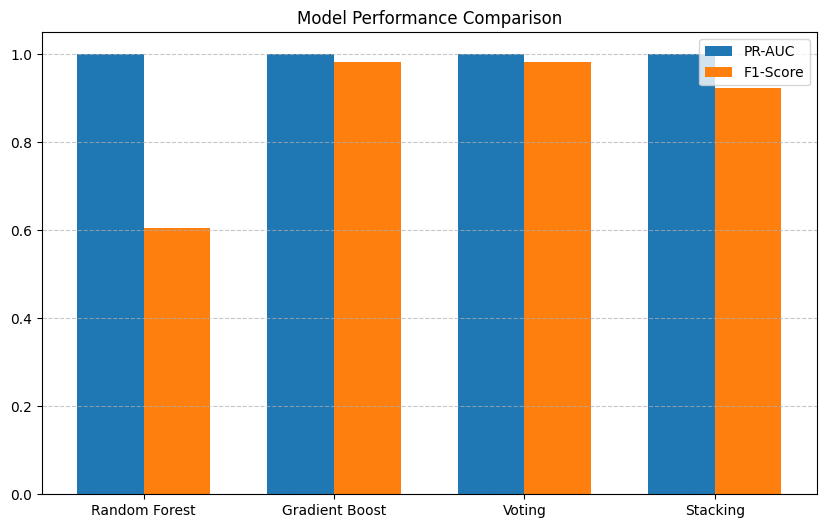

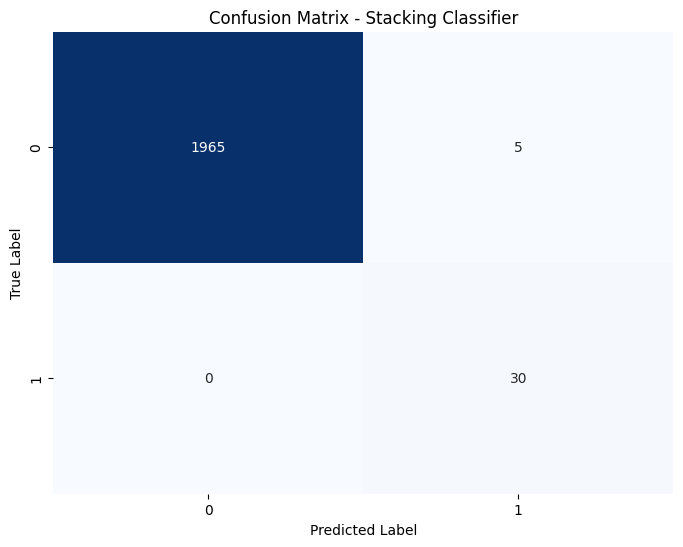

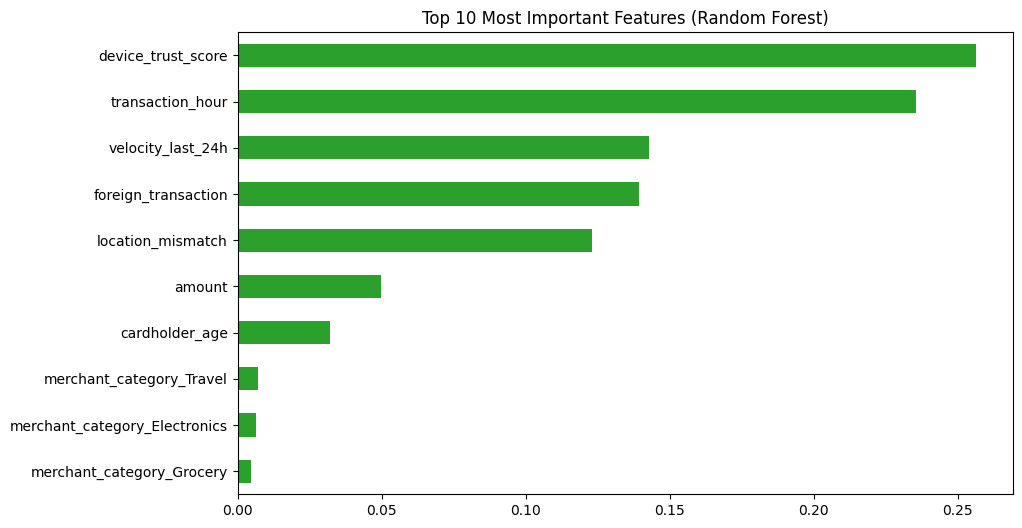

In [14]:
# 1. Comparison Bar Chart for Models
model_names = list(models.keys())
pr_auc = []
f1 = []

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    pr_auc.append(average_precision_score(y_test, y_proba))
    f1.append(f1_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35
plt.bar(x - width/2, pr_auc, width, label='PR-AUC', color='#1f77b4')
plt.bar(x + width/2, f1, width, label='F1-Score', color='#ff7f0e')
plt.xticks(x, model_names)
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Confusion Matrix Visual (For the Stacking model as an example)
best_model = stacking 
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Stacking Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Feature Importance (Random Forest example)
importances = rf.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='#2ca02c')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.show()